# Example for consensus
This notebook demonstrates how the multiplicative weights algorithm can enhance the robustness of a consensus algorithm against Byzantine attacks.

## 1. Set some global parameters:

In [1]:
import multiprocessing as mp
import numpy as np
import numpy.typing as npt

if __name__ == "__main__":
    N_STATE = 3
    N_ITER = 2000
    ALPHA = 0.3

    NORMAL_LB = -100.0  # Lower bound of normal nodes' initial state values
    NORMAL_UB = 100.0  # Upper bound of normal nodes' initial state values

## 2. Define the graph topology and characterize the behavior of Byzantine nodes.
### (1) Define the graph

We consider a network consisting of two categories of nodes with corresponding edges:

```python
NORMAL_NODES = [...]
NORMAL_EDGES = [...]

BYZANTINE_NODES = [...]
BYZANTINE_EDGES = [...]
```

The overall network is formed by the union of the normal and Byzantine nodes and edges:

$$
\mathcal{I} = \mathcal{I}_\text{normal} \cup \mathcal{I}_\text{Byz}, \quad \mathcal{E} = \mathcal{E}_\text{normal} \cup \mathcal{E}_\text{Byz}.
$$

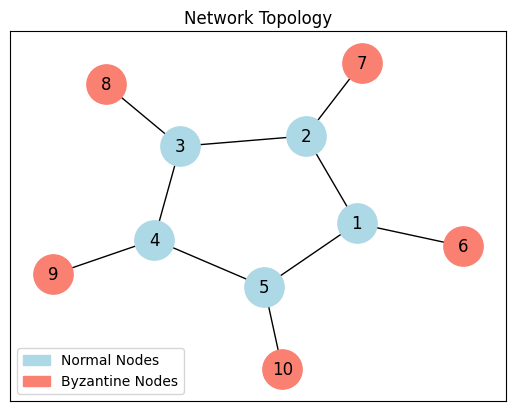

In [2]:
def graph(nodes: list[str], edges: list[tuple[str, str]]) -> None:
    from logging import basicConfig, INFO

    basicConfig(level=INFO)

    from topolink import Graph

    graph = Graph(nodes, edges)

    graph.deploy()


if __name__ == "__main__":
    # Simple case
    NORMAL_NODES = ["1", "2", "3", "4", "5"]
    NORMAL_EDGES = [("1", "2"), ("2", "3"), ("3", "4"), ("4", "5"), ("5", "1")]
    BYZANTINE_NODES = ["6", "7", "8", "9", "10"]
    BYZANTINE_EDGES = [("1", "6"), ("2", "7"), ("3", "8"), ("4", "9"), ("5", "10")]

    # Moderate case
    # NORMAL_NODES = ["1", "2", "3", "4", "5", "6", "7"]
    # NORMAL_EDGES = [
    #     ("1", "2"),
    #     ("2", "3"),
    #     ("3", "4"),
    #     ("4", "5"),
    #     ("5", "1"),
    #     ("1", "6"),
    #     ("2", "7"),
    # ]
    # BYZANTINE_NODES = ["8", "9", "10"]
    # BYZANTINE_EDGES = [("3", "8"), ("4", "9"), ("5", "10")]

    # Extreme case
    # NORMAL_NODES = ["1", "2", "3", "4", "5"]
    # NORMAL_EDGES = [
    #     ("1", "2"),
    #     ("2", "3"),
    #     ("3", "4"),
    #     ("4", "5"),
    #     ("5", "1"),
    #     ("2", "5"),
    # ]
    # BYZANTINE_NODES = ["6", "7", "8", "9", "10", "11", "12"]
    # BYZANTINE_EDGES = [
    #     ("1", "6"),
    #     ("2", "7"),
    #     ("3", "8"),
    #     ("4", "9"),
    #     ("5", "10"),
    #     ("2", "11"),
    #     ("2", "12"),
    # ]

    # Conservative case
    # NORMAL_NODES = ["1", "2", "3", "4", "5", "6", "7"]
    # NORMAL_EDGES = [
    #     ("1", "2"),
    #     ("2", "3"),
    #     ("3", "4"),
    #     ("4", "5"),
    #     ("5", "1"),
    #     ("1", "6"),
    #     ("5", "6"),
    #     ("3", "7"),
    #     ("4", "7"),
    # ]
    # BYZANTINE_NODES = []
    # BYZANTINE_EDGES = []

    NODES = NORMAL_NODES + BYZANTINE_NODES
    EDGES = NORMAL_EDGES + BYZANTINE_EDGES

    N_NORMAL = len(NORMAL_NODES)
    N_BYZANTINE = len(BYZANTINE_NODES)
    N_NODES = N_NORMAL + N_BYZANTINE

    import matplotlib.pyplot as plt
    import networkx as nx

    fig, ax = plt.subplots()
    ax.set_title("Network Topology")

    G = nx.Graph()
    G.add_nodes_from(NODES)
    G.add_edges_from(EDGES)

    pos = nx.spring_layout(G, seed=11, k=0.8)

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=NORMAL_NODES,
        node_color="lightblue",
        node_size=800,
        ax=ax,
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=BYZANTINE_NODES,
        node_color="salmon",
        node_size=800,
        ax=ax,
    )

    nx.draw_networkx_edges(G, pos, ax=ax)
    nx.draw_networkx_labels(G, pos, ax=ax)

    import matplotlib.patches as mpatches

    blue_patch = mpatches.Patch(color="lightblue", label="Normal Nodes")
    red_patch = mpatches.Patch(color="salmon", label="Byzantine Nodes")

    ax.legend(handles=[blue_patch, red_patch], loc="lower left")

### (2) Define the behavior of Byzantine nodes

A Byzantine node ignores the states of its neighbors.
Let the state of node $i$ at iteration $t$ be denoted as $x_i(t)$.
Then the update rule for a Byzantine node can be described as:

1. **Keep state constant:**
   $$
   x_i(t + 1) = x_i(t)
   $$

2. **Update state randomly:**
   $$
   x_i(t) \sim \mathcal{U}(a, b)
   $$
   where $\mathcal{U}(a, b)$ denotes a uniform random variable in the range $[a, b]$, which represents the possible values that the Byzantine node can take.

3. **Add perturbation:**
   $$
   x_i(t + 1) = x_i(t) - \alpha \sum_{j \in \mathcal{N}_i}(x_i(t) - x_j(t)) + \eta_i(t)
   $$
   where $\eta_i(t)$ is an interference term (noise) that can be modeled as either deterministic or stochastic, e.g.
   $$
   \eta_i(t) \sim \mathcal{U}(a, b).
   $$
   This form represents a Byzantine node that actively injects perturbations into its state to disrupt the consensus process.

In [3]:
def byzantine_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> npt.NDArray[np.float64]:
    byz_type = "disturbance"
    lower_bound = -100.0
    upper_bound = 100.0

    from numpy import zeros
    from numpy.random import seed, uniform
    from topolink import NodeHandle

    nh = NodeHandle(name)

    x = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    x[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        laplacian = nh.laplacian(x[k])

        if byz_type == "constant":
            x[k + 1] = x[k]
        elif byz_type == "random":
            x[k + 1] = uniform(lower_bound, upper_bound, n_state)
        elif byz_type == "disturbance":
            disturbance = uniform(-1.0, 1.0, n_state)
            x[k + 1] = x[k] - laplacian * alpha + disturbance

    return x

## 3. Execute a standard consensus algorithm

In our system, the state of each node is updated using a consensus iteration. Let $x_i(t) \in \mathbb{R}^d$ denote the state of node $i$ at iteration $t$, where $d$ is the dimension of the state.
The consensus update is given by

$$
x_i(t + 1) = x_i(t) - \alpha \sum_{j \in \mathcal{N}_i}(x_i(t) - x_j(t))
$$

where $\mathcal{N}_i$ is the set of neighbors of node $i$, and $\alpha > 0$ is the step size.

### (1) Run the algorithm

In [4]:
def baseline_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> npt.NDArray[np.float64]:
    lower_bound = -100.0
    upper_bound = 100.0

    from numpy import zeros
    from numpy.random import uniform, seed
    from topolink import NodeHandle

    nh = NodeHandle(name)

    x = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    x[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        x[k + 1] = x[k] - nh.laplacian(x[k]) * alpha

    return x


if __name__ == "__main__":
    with mp.Pool(N_NODES + 1) as pool:
        baseline_results = {
            i: pool.apply_async(baseline_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in NORMAL_NODES
        }
        byzantine_results = {
            i: pool.apply_async(byzantine_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in BYZANTINE_NODES
        }
        pool.apply(graph, args=(NODES, EDGES))

        baseline_data = {i: result.get() for i, result in baseline_results.items()}
        byzantine_data = {i: result.get() for i, result in byzantine_results.items()}

INFO:topolink.graph:Graph 'default' running on: 10.20.13.39:46379
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '3' joined graph 'default' from 10.20.13.39:45013.
INFO:topolink.graph:Node '7' joined graph 'default' from 10.20.13.39:45365.
INFO:topolink.graph:Node '9' joined graph 'default' from 10.20.13.39:45601.
INFO:topolink.graph:Node '8' joined graph 'default' from 10.20.13.39:44845.
INFO:topolink.graph:Node '1' joined graph 'default' from 10.20.13.39:45749.
INFO:topolink.graph:Node '5' joined graph 'default' from 10.20.13.39:45361.
INFO:topolink.graph:Node '10' joined graph 'default' from 10.20.13.39:45785.
INFO:topolink.graph:Node '6' joined graph 'default' from 10.20.13.39:45183.
INFO:topolink.graph:Node '4' joined graph 'default' from 10.20.13.39:45775.
INFO:topolink.graph:Node '2' joined graph 'default' from 10.20.13.39:45957.
INFO:topolink.graph:Graph 'default' registration complete.
INFO:topolink.graph:Sent neighbor information

### (2) Visualize the Results

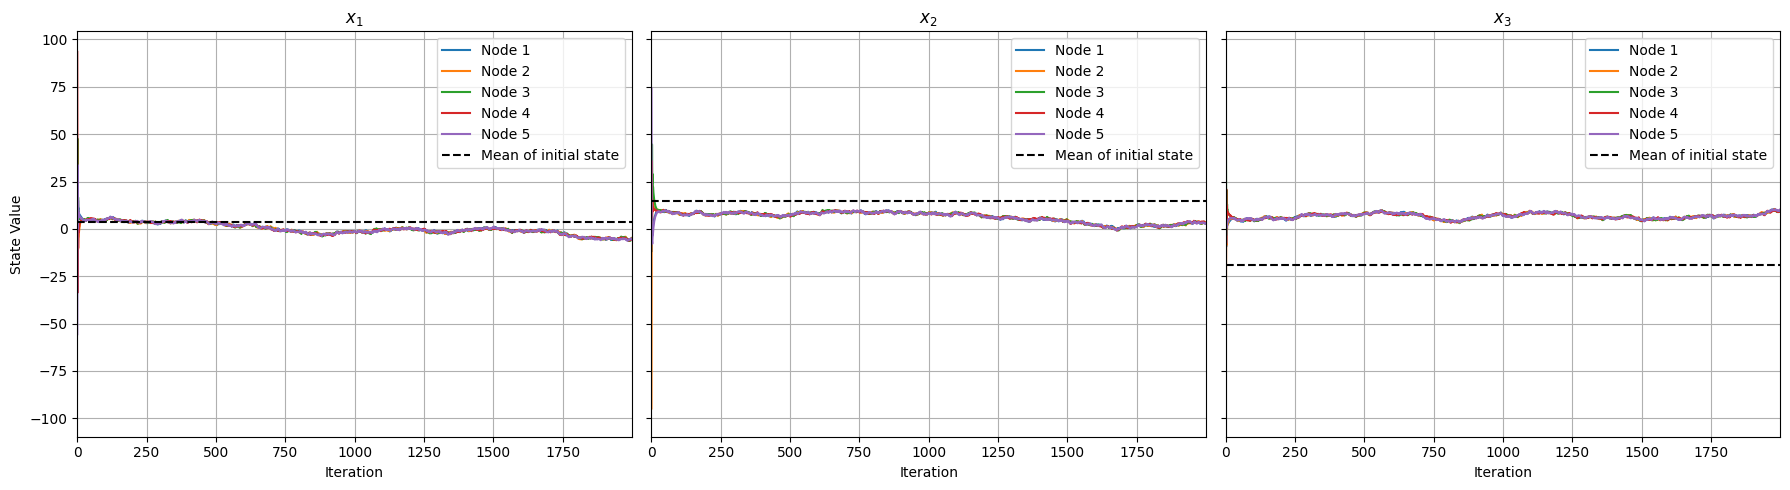

In [5]:
if __name__ == "__main__":
    import typing as tp
    import matplotlib.pyplot as plt
    import matplotlib.axes as maxes

    axes1: tp.Sequence[maxes.Axes]
    fig1, axes1 = plt.subplots(1, N_STATE, figsize=(18, 5), sharey=True)

    for i in NORMAL_NODES:
        states = baseline_data[i]
        for j in range(N_STATE):
            axes1[j].plot(states[:, j], label=f"Node {i}")

    initial_states = [baseline_data[i][0, :] for i in NORMAL_NODES]
    mean_states: npt.NDArray[np.float64] = np.average(initial_states, axis=0)

    for j in range(N_STATE):
        axes1[j].axhline(
            mean_states[j],
            color="k",
            linestyle="--",
            label="Mean of initial state",
        )

    for j in range(N_STATE):
        axes1[j].set_xlabel("Iteration")
        axes1[j].set_xlim(0, N_ITER - 1)
        axes1[j].legend()
        axes1[j].set_title(f"$x_{j + 1}$")
        axes1[j].grid()

    axes1[0].set_ylabel("State Value")

    fig1.tight_layout()

## 4. Exponential reputation-based consensus algorithm
---
### Multiplicative weights update

For a system with $n$ experts, each expert $i$ is assigned a weight $\omega_i(t)$ at time step $t$.
At this step, expert $i$ incurs a loss $l_i(t)$, and its weight is subsequently updated according to one of the following rules.

#### 1. Linear update
$$
\omega_i(t + 1) = \omega_i(t) (1 - \eta l_i(t))
$$
where $\eta$ is the learning rate parameter.

This linear update is simple to compute but can lead to negative weights when $\eta l_i(t) > 1$, and it is less convenient for theoretical analysis.

#### 2. Exponential update (Hedge)
In practice, the exponential update is typically preferred:
$$
\boxed{\omega_i(t + 1) = \omega_i(t) e^{-\eta l_i(t)}}
$$
where $\eta > 0$ is the learning rate.

For small values of $\eta$, note that:
$$
e^{-\eta l_i(t)} \approx 1 - \eta l_i(t),
$$
so the linear rule can be viewed as a first-order approximation of the exponential update.

It is often more convenient to express this update in terms of the **cumulative loss**:
$$
L_i(t) = \sum_{\tau = 1}^{t} l_i(\tau).
$$
Substituting this definition into the recursive rule yields the following closed-form expression:
$$
\boxed{\omega_i(t) = \exp(-\eta L_i(t))}.
$$
This formulation is commonly used in practice, as it avoids repeated multiplications and makes explicit how each expert’s weight decays exponentially with its cumulative loss.

Finally, to obtain a valid probability distribution over experts, the normalized weights are defined as:
$$
p_i(t) = \frac{\omega_i(t)}{\sum_j \omega_j(t)}.
$$
Here, $p_i(t)$ represents the normalized importance (or probability) assigned to expert $i$ at round $t$.


> **Note**
> The following notation is independent of the above; the above was written according to the original paper.

---
### Loss function

#### 1. Quasi geometric median loss
For each node $i$ and each neighbor $j \in \mathcal{N}_i$, we define the loss as

$$
l_{ij}(t) = \sum_{v \in \mathcal{N}_i} \frac{\| x_j(t) - x_v(t) \|}{d_i},
$$

where $x_j(t)$ denotes the state received from neighbor $j$ at iteration $t$, $\mathcal{N}_i$ is the set of neighbors of node $i$, and $d_i = |\mathcal{N}_i|$ denotes its degree.

This loss quantifies the local geometric inconsistency between neighbor $j$ and the remaining neighbors of node $i$. It can be viewed as a **quasi–geometric median** measure, since it approximates the notion of the **geometric median**, defined as

$$
{gm}_i = \arg\min_x \sum_{v \in \mathcal{N}_i} \|x - x_v\|.
$$

Neighbors closer to this geometric median yield smaller losses, while outliers or Byzantine neighbors exhibit larger ones.

#### 2. Geometric median loss
Finally, we define the **geometric median loss**, which directly measures the distance of each neighbor's state to the true geometric median:

$$
l_{ij}(t) = \| x_j(t) - {gm}_{i}(t) \|,
$$

where 
$$
{gm}_{i}(t) = \arg\min_x \sum_{v \in \mathcal{N}_i} \| x - x_v(t) \|
$$
is the **geometric median** of node $i$’s neighbors at iteration $t$.

Computing the geometric median at each iteration requires solving a non-smooth convex optimization problem, which can be computationally expensive compared to the quasi geometric median or coordinate-wise median.

#### 3. Coordinate-wise median loss
Alternatively, we define a **coordinate-wise median loss**, which quantifies the deviation of each neighbor's state from the coordinate-wise median of all neighbors:

$$
l_{ij}(t) = \| x_j(t) - {cm}_{i}(t) \|_1,
$$

where 
$$
{cm}_{i}(t) = \arg\min_x \sum_{v \in \mathcal{N}_i} \| x - x_v(t) \|_1
$$
denotes the coordinate-wise median of node $i$’s neighbors at iteration $t$.

Note that since the coordinate-wise median is computed independently across coordinates, ${cm}_i(t)$ is **not necessarily a convex combination of the neighbors and may even lie outside their convex hull**.

#### 4. Mean loss
We define the **mean loss**, which measures each neighbor’s deviation from the average of all neighbor states:

$$
l_{ij}(t) = \| x_j(t) - m_{i}(t) \|
$$

where
$$
m_{i}(t) = \frac{1}{d_i} \sum_{v \in \mathcal{N}_i} x_v(t)
$$

denotes the mean state of node $i$'s neighbors at iteration $t$.

Although the mean is theoretically non-robust and highly sensitive to outliers or Byzantine neighbors, its empirical performance in our setting turns out to be **surprisingly strong**.

#### 5. Trimmed-mean loss
We define the **trimmed-mean loss**, which mitigates the influence of extreme neighbor values by averaging only the central subset of neighbor states:

$$
l_{ij}(t) = \| x_j(t) - tm_{i}(t) \|
$$

where ${tm}_i$ is the coordinate-wise trimmed mean, computed by removing the largest and smallest $f$ values in each coordinate and averaging the remaining ones:

$$
tm_{i,k}(t) = \frac{1}{d_i - 2f} \sum_{v \in S_{i,k}(t)} x_{v,k}(t)
$$

with $S_{i,k}(t)$ being the set of neighbors whose $k$-th coordinate lies within the central $d_i - 2f$ range after discarding $f$ largest and $f$ smallest values.

---
### Discounted memory

In standard implementations, the exponential weighting rule is typically based on the **cumulative loss**:

$$
\omega_{ij}(t) = \exp(-\eta\, L_{ij}(t)),
$$

where $L_{ij}(t)$ sums the losses over all previous iterations.

However, using cumulative loss has two limitations in our setting:
1. **Past information may be misleading.** Due to the highly dynamic nature of Byzantine attacks, a malicious node could behave honestly for several rounds before attacking. Retaining long-term memory would cause such nodes to maintain high trust, compromising system reliability.
2. **Losses among honest nodes may differ even after consensus.** When honest neighbors converge, their cumulative losses are generally not equal. Standard multiplicative weight update (MWU) algorithms would then favor one "best" node over others, resulting in unequal weights among honest nodes. This contradicts our goal of **treating all honest nodes equally**.

To address these issues while still preserving short-term memory, we adopt a **decayed cumulative loss** with a **forgetting factor** $\lambda \in (0,1]$:

$$
\tilde{L}_{ij}(t) = \lambda\, \tilde{L}_{ij}(t - 1) + l_{ij}(t).
$$

Accordingly, the weight update becomes

$$
\boxed{\omega_{ij}(t) = \exp(-\eta\, \tilde{L}_{ij}(t))}.
$$

This formulation ensures that recent observations have a stronger influence, mitigating the impact of outdated information while retaining a smoothed history. By adjusting $\lambda$, the system can balance responsiveness to sudden changes against stability in the presence of benign fluctuations.

When $\lambda = 0$, the formulation degenerates to the instantaneous-loss case.

---
### The proposed algorithm

#### Initialization

For each node $i$:

- Initialize the local state randomly:  
  $$
  x_i(0) \sim \text{Random}.
  $$  

- Initialize the cumulative loss:  
  $$
  \tilde{L}_{ij}(0) = 0, \quad \forall j \in \mathcal{N}_i.
  $$  


#### Iterative Update (for each time step $t = 0,1,2,\dots$)

For each node $i$, repeat:

1. Exchange the current state $x_i(t)$ with neighbors and receive  
   $$
   x_j(t), \quad \forall j \in \mathcal{N}_i.
   $$  

2. Observe a biased estimate of the honest neighbors’ average (using the geometric median, coordinate-wise median, or trimmed mean) and analyze the corresponding losses
   $$
   y_i(t) = \mathcal{B}_i\big(\{x_j(t)\}_{j \in \mathcal{N}_i}\big), \qquad l_{ij}(t) = \ell\big(x_j(t), y_i(t)\big), \quad \forall j \in \mathcal{N}_i.
   $$

3. Update probability distribution

   **Form 1 (discounted loss + softmax)**
   $$
   \tilde{L}_{ij}(t+1)=\lambda \tilde{L}_{ij}(t)+l_{ij}(t),\qquad p_{ij}(t+1)=\frac{\exp\!\big(-\eta \tilde{L}_{ij}(t+1)\big)}{\sum_{k\in\mathcal N_i}\exp\!\big(-\eta \tilde{L}_{ik}(t+1)\big)}.
   $$

   **Form 2 (KL-regularized update)**
   $$
   p_i(t+1)=\arg\min_{p\in \Delta(\mathcal N_i)}
   \left\{\langle p,l_i(t)\rangle+\frac{1}{\eta}\mathrm{KL}\!\left(p\ \|\ p_i(t)^\lambda\right)\right\},
   $$
   where
   $$
   \Delta(\mathcal N_i)=\{p\in\mathbb R_+^{|\mathcal N_i|}:\sum_{j\in\mathcal N_i}p_{ij}=1\}, \qquad
   p_i(t) = [p_{ij}(t)]_{j\in\mathcal N_i}, \qquad l_i(t) = [l_{ij}(t)]_{j\in\mathcal N_i}, \qquad
   p_i(t)^\lambda=\Bigg[\frac{p_{ij}(t)^\lambda}{\sum_{k\in\mathcal N_i}p_{ik}(t)^\lambda}\Bigg]_{j\in\mathcal N_i}.
   $$

4. Compute the aggregated prediction and update the local state  
   $$
   x_i(t+1) = (1 - \alpha) x_i(t) + \alpha \sum_{j \in \mathcal{N}_i} p_{ij}(t+1)\, x_j(t),
   $$
   where $\alpha \in (0,1)$ balances the historical state and the aggregated estimate.

---

### (1) Run the algorithm

In [6]:
def xrepc_node(
    name: str,
    n_state: int,
    alpha: float,
    n_iter: int,
) -> tuple[npt.NDArray[np.float64], dict[str, npt.NDArray[np.float64]]]:
    lower_bound = -100.0
    upper_bound = 100.0

    from numpy import zeros
    from numpy.random import uniform, seed
    from topolink import NodeHandle

    nh = NodeHandle(name)

    from xrepc import XRepC

    agent = XRepC(nh.neighbor_names, alpha, eta=0.15, decay=0.9)

    x = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    x[0] = uniform(lower_bound, upper_bound, n_state)

    probs = {neighbor: zeros(n_iter - 1) for neighbor in nh.neighbor_names}

    for k in range(n_iter - 1):
        # Broadcast current state (make decision) and gather neighbors' states (observe results)
        nh.broadcast(x[k])
        x_js = nh.gather()

        # Compute new state
        x[k + 1] = agent.aggregate(x[k], x_js)

        # Record normalized weights history
        p = agent.probs
        for j in nh.neighbor_names:
            probs[j][k] = p[j]

    return x, probs


if __name__ == "__main__":
    with mp.Pool(N_NODES + 1) as pool:
        xrepc_results = {
            i: pool.apply_async(xrepc_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in NORMAL_NODES
        }
        byzantine_results = {
            i: pool.apply_async(byzantine_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in BYZANTINE_NODES
        }
        pool.apply(graph, args=(NODES, EDGES))

        xrepc_data = {i: node.get() for i, node in xrepc_results.items()}
        byzantine_data = {i: node.get() for i, node in byzantine_results.items()}

INFO:topolink.graph:Graph 'default' running on: 10.20.13.39:45225
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '1' joined graph 'default' from 10.20.13.39:46609.
INFO:topolink.graph:Node '4' joined graph 'default' from 10.20.13.39:45319.
INFO:topolink.graph:Node '6' joined graph 'default' from 10.20.13.39:45031.
INFO:topolink.graph:Node '9' joined graph 'default' from 10.20.13.39:44641.
INFO:topolink.graph:Node '10' joined graph 'default' from 10.20.13.39:45029.
INFO:topolink.graph:Node '2' joined graph 'default' from 10.20.13.39:45363.
INFO:topolink.graph:Node '7' joined graph 'default' from 10.20.13.39:44643.
INFO:topolink.graph:Node '5' joined graph 'default' from 10.20.13.39:44865.
INFO:topolink.graph:Node '8' joined graph 'default' from 10.20.13.39:46185.
INFO:topolink.graph:Node '3' joined graph 'default' from 10.20.13.39:45807.
INFO:topolink.graph:Graph 'default' registration complete.
INFO:topolink.graph:Sent neighbor information

### (2) Visualize the Results

#### 1. State evolution for each normal node

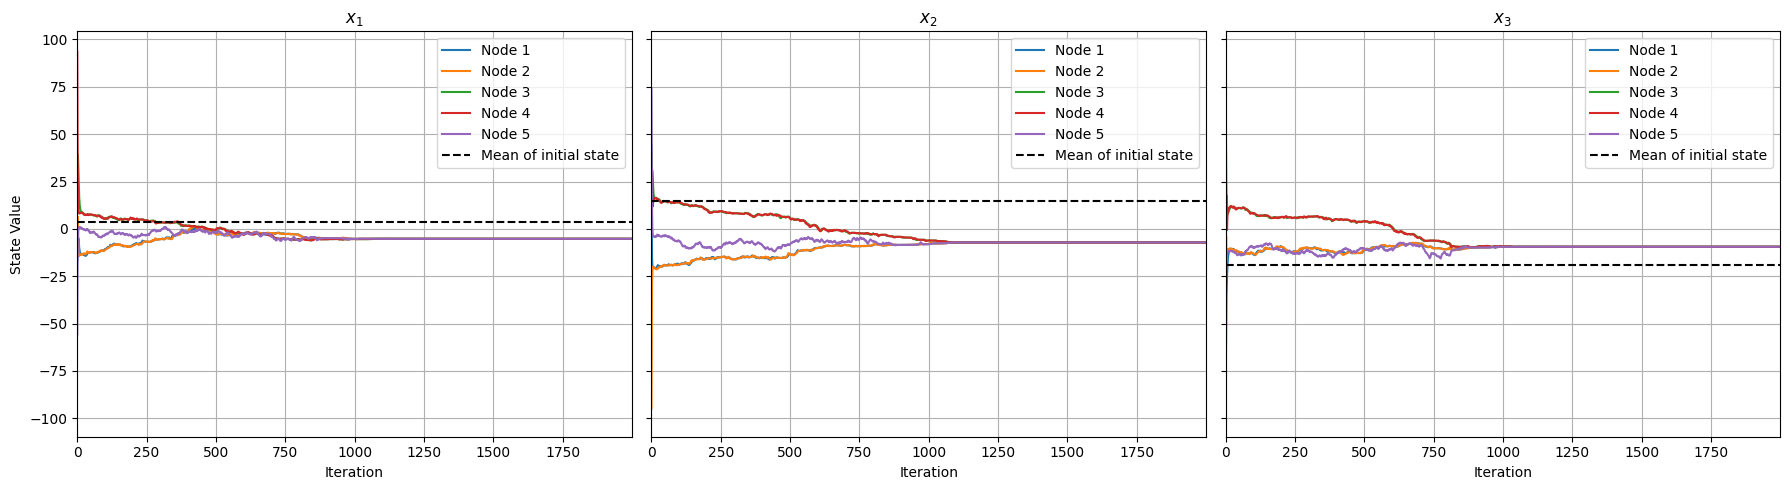

In [7]:
if __name__ == "__main__":
    import typing as tp
    import matplotlib.pyplot as plt
    import matplotlib.axes as maxes

    axes2: tp.Sequence[maxes.Axes]
    fig2, axes2 = plt.subplots(1, N_STATE, figsize=(18, 5), sharey=True)

    xrepc_states = {i: xrepc_data[i][0] for i in NORMAL_NODES}

    for i in NORMAL_NODES:
        states = xrepc_states[i]
        for j in range(N_STATE):
            axes2[j].plot(states[:, j], label=f"Node {i}")

    initial_states = [xrepc_states[i][0, :] for i in NORMAL_NODES]
    mean_states: npt.NDArray[np.float64] = np.average(initial_states, axis=0)

    for j in range(N_STATE):
        axes2[j].axhline(
            mean_states[j], color="k", linestyle="--", label="Mean of initial state"
        )

    for j in range(N_STATE):
        axes2[j].set_xlabel("Iteration")
        axes2[j].set_xlim(0, N_ITER - 1)
        axes2[j].legend()
        axes2[j].set_title(f"$x_{j + 1}$")
        axes2[j].grid()

    axes2[0].set_ylabel("State Value")

    fig2.tight_layout()

#### 2. Weight evolution for each node

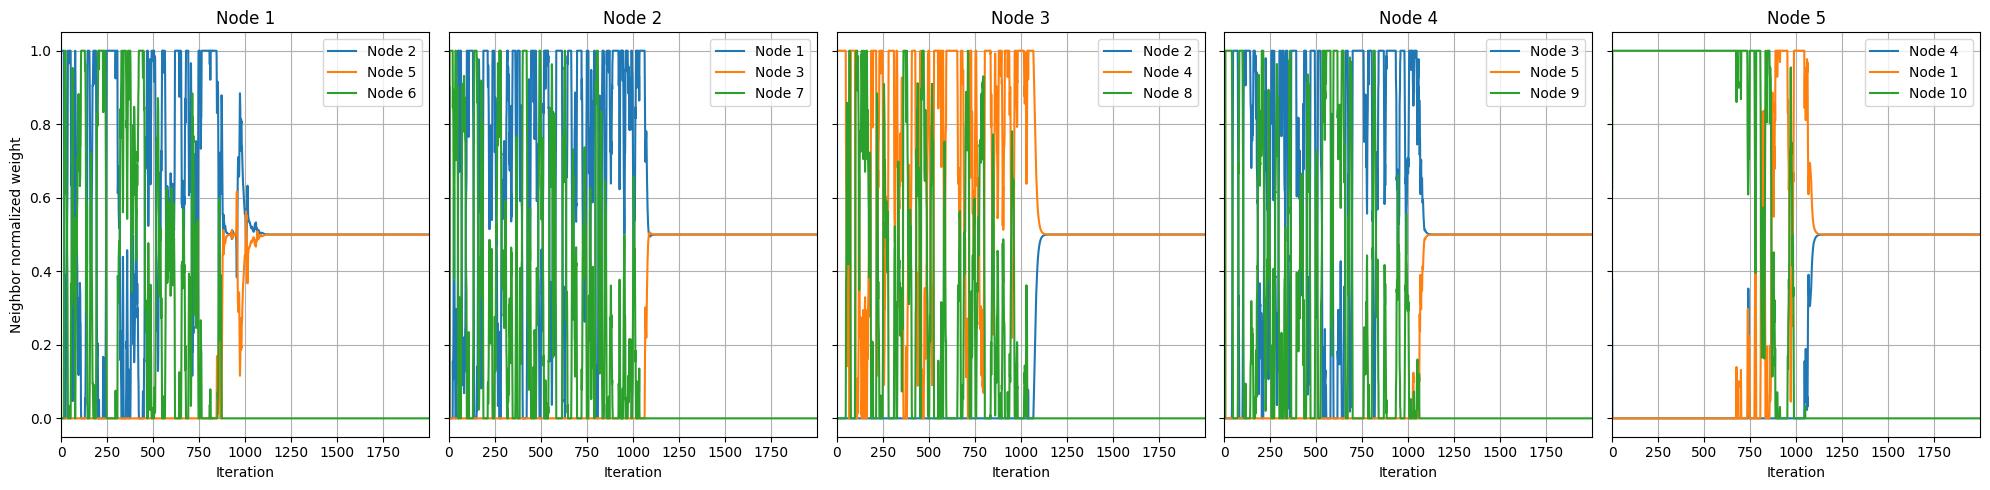

In [8]:
if __name__ == "__main__":
    axes3: tp.Sequence[maxes.Axes]
    fig3, axes3 = plt.subplots(1, N_NORMAL, figsize=(20, 5), sharey=True)

    xrepc_probs = {i: xrepc_data[i][1] for i in NORMAL_NODES}

    for i, ax in zip(NORMAL_NODES, axes3):
        probs_for_i = xrepc_probs[i]
        for j in probs_for_i:
            ax.plot(probs_for_i[j], label=f"Node {j}")
        ax.set_title(f"Node {i}")
        ax.set_xlabel("Iteration")
        ax.set_xlim(0, N_ITER - 1)
        ax.legend()
        ax.grid()

    axes3[0].set_ylabel("Neighbor normalized weight")

    fig3.tight_layout()

## 5. Reputation-based consensus

#### 1. Compute reputation
Each node $i$ first estimates the preliminary reputation of its neighbor $j \in \mathcal{N}_i$ based on their state difference:
$$
\tilde{c}_{ij}^{(k+1)} =
\begin{cases}
1 - \sum_{v \in \mathcal{N}_i} \frac{\| x_j^{(k)} - x_v^{(k)} \|}{| \mathcal{N}_i |}, & j \in \mathcal{N}_i, \\[6pt]
0, & \text{otherwise.}
\end{cases}
$$
This formulation penalizes neighbors whose states significantly deviate from others in $\mathcal{N}_i$, thereby reducing their reputational weight.

#### 2. Normalize reputation
To ensure comparability across different neighbors, the reputations are normalized within the neighborhood:
$$
\tilde{\tilde{c}}_{ij}^{(k+1)} =
\begin{cases}
\dfrac{\tilde{c}_{ij}^{(k+1)} - \min\nolimits_{v \in \mathcal{N}_i}^f \tilde{c}_{iv}^{(k+1)}}
{\max\nolimits_{v \in \mathcal{N}_i} \tilde{c}_{iv}^{(k+1)} - \min\nolimits_{v \in \mathcal{N}_i}^f \tilde{c}_{iv}^{(k+1)}},
& \text{if not all } \tilde{c}_{iv}^{(k+1)} \text{ are equal}, \\[10pt]
1, & \text{otherwise.}
\end{cases}
$$

#### 3. Trim reputation with confidence $\epsilon$
To prevent reputations from vanishing and to maintain minimal trust even for low-confidence neighbors, a confidence-based lower bound is applied:
$$
c_{ij}^{(k+1)} =
\begin{cases}
\tilde{\tilde{c}}_{ij}^{(k+1)}, & \text{if} \quad \tilde{\tilde{c}}_{ij}^{(k+1)} > 0, \\[6pt]
\epsilon^{k+1}, & \text{otherwise.}
\end{cases}
$$

Here, $\min^f$ denotes a generalized order statistic defined as follows: it is obtained by first removing duplicates from the multiset $\{\tilde{c}_{iv}^{(k+1)} : v \in \mathcal{N}_i\}$ and then selecting the $f$-th smallest distinct value.
If this value happens to coincide with the maximum element of the multiset,  the $(f-1)$-th smallest distinct value is used instead.

#### 4. Aggregate states
Finally, each node updates its state by aggregating information from its neighbors, weighted by the trimmed reputations:
$$
x_i^{k+1} = x_i^{(k)} - \alpha \frac{\sum_{j \in \mathcal{N}_i} c_{ij}^{(k)} (x_i^{(k)} - x_j^{(k)})}{\sum_{j \in \mathcal{N}_i} c_{ij}^{(k)}}.
$$
This adaptive aggregation allows nodes to gradually adjust their states toward more reputable neighbors while mitigating the influence of unreliable ones.

---

### (1) Run the algorithm

In [9]:
def repc_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> tuple[npt.NDArray[np.float64], dict[str, npt.NDArray[np.float64]]]:
    lower_bound = -100.0
    upper_bound = 100.0

    from topolink import NodeHandle

    nh = NodeHandle(name)

    from xrepc.baselines import RepC

    agent = RepC(nh.neighbor_names, alpha)

    from numpy import zeros
    from numpy.random import uniform, seed

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    probs = {neighbor: zeros(n_iter - 1) for neighbor in nh.neighbor_names}

    for k in range(n_iter - 1):
        # Update state
        nh.broadcast(states[k])
        state_js = nh.gather()

        # Compute new state
        states[k + 1] = agent.aggregate(states[k], state_js)

        # Record normalized weights history
        p = agent.probs
        for j in nh.neighbor_names:
            probs[j][k] = p[j]

    return states, probs


if __name__ == "__main__":
    with mp.Pool(N_NODES + 1) as pool:
        repc_results = {
            i: pool.apply_async(repc_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in NORMAL_NODES
        }
        byzantine_results = {
            i: pool.apply_async(byzantine_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in BYZANTINE_NODES
        }
        pool.apply(graph, args=(NODES, EDGES))

        repc_data = {i: node.get() for i, node in repc_results.items()}
        byzantine_data = {i: node.get() for i, node in byzantine_results.items()}

INFO:topolink.graph:Graph 'default' running on: 10.20.13.39:44723
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '10' joined graph 'default' from 10.20.13.39:46509.
INFO:topolink.graph:Node '7' joined graph 'default' from 10.20.13.39:46181.
INFO:topolink.graph:Node '8' joined graph 'default' from 10.20.13.39:46461.
INFO:topolink.graph:Node '6' joined graph 'default' from 10.20.13.39:46527.
INFO:topolink.graph:Node '5' joined graph 'default' from 10.20.13.39:46091.
INFO:topolink.graph:Node '4' joined graph 'default' from 10.20.13.39:45405.
INFO:topolink.graph:Node '3' joined graph 'default' from 10.20.13.39:46313.
INFO:topolink.graph:Node '9' joined graph 'default' from 10.20.13.39:45757.
INFO:topolink.graph:Node '2' joined graph 'default' from 10.20.13.39:45401.
INFO:topolink.graph:Node '1' joined graph 'default' from 10.20.13.39:45077.
INFO:topolink.graph:Graph 'default' registration complete.
INFO:topolink.graph:Sent neighbor information

### (2) Visualize the Results

#### 1. State evolution for each normal node

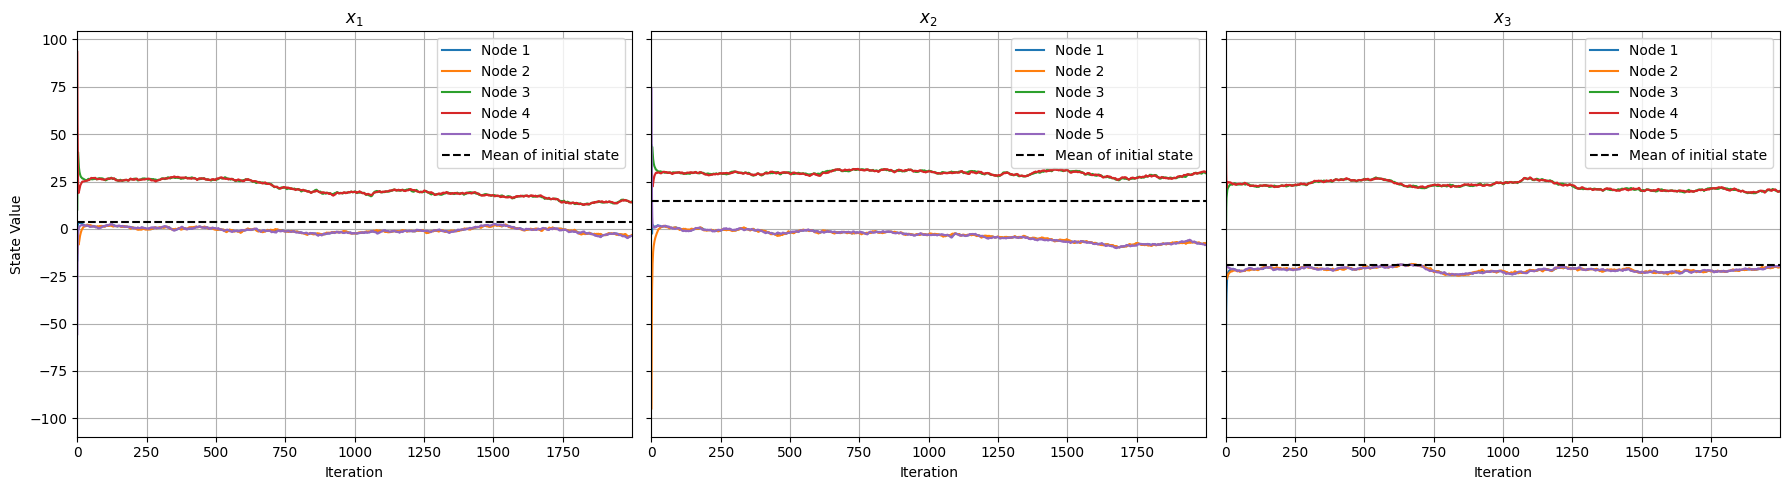

In [10]:
if __name__ == "__main__":
    import typing as tp
    import matplotlib.pyplot as plt
    import matplotlib.axes as maxes

    axes4: tp.Sequence[maxes.Axes]
    fig4, axes4 = plt.subplots(1, N_STATE, figsize=(18, 5), sharey=True)

    repc_states = {i: repc_data[i][0] for i in NORMAL_NODES}

    for i in NORMAL_NODES:
        states = repc_states[i]
        for j in range(N_STATE):
            axes4[j].plot(states[:, j], label=f"Node {i}")

    initial_states = [repc_states[i][0, :] for i in NORMAL_NODES]
    mean_states: npt.NDArray[np.float64] = np.sum(initial_states, axis=0) / N_NORMAL

    for j in range(N_STATE):
        axes4[j].axhline(
            mean_states[j], color="k", linestyle="--", label="Mean of initial state"
        )

    for j in range(N_STATE):
        axes4[j].set_xlabel("Iteration")
        axes4[j].set_xlim(0, N_ITER - 1)
        axes4[j].legend()
        axes4[j].set_title(f"$x_{j + 1}$")
        axes4[j].grid()

    axes4[0].set_ylabel("State Value")

    fig4.tight_layout()

#### 2. Weight evolution for each node

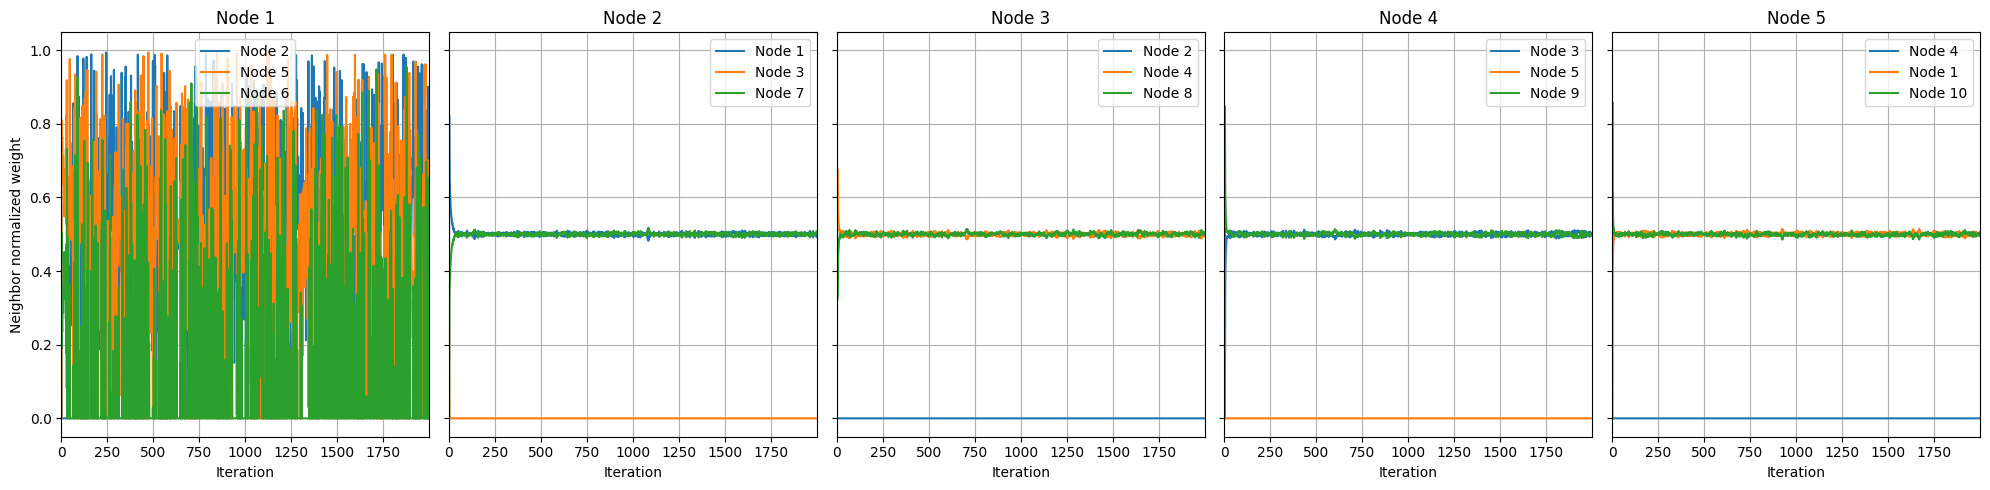

In [11]:
if __name__ == "__main__":
    axes5: tp.Sequence[maxes.Axes]
    fig5, axes5 = plt.subplots(1, N_NORMAL, figsize=(20, 5), sharey=True)

    repc_probs = {i: repc_data[i][1] for i in NORMAL_NODES}

    for i, ax in zip(NORMAL_NODES, axes5):
        probs_for_i = repc_probs[i]
        for j in probs_for_i:
            ax.plot(probs_for_i[j], label=f"Node {j}")
        ax.set_title(f"Node {i}")
        ax.set_xlabel("Iteration")
        ax.set_xlim(0, N_ITER - 1)
        ax.legend()
        ax.grid()

    axes5[0].set_ylabel("Neighbor normalized weight")

    fig5.tight_layout()

## 6. Difficulties in Theoretical Proof

Although the algorithm works well in practice, the following issues make a rigorous theoretical analysis challenging.

1. **No robust nominal controller.**  
   The controller cannot tolerate Byzantine nodes without the learning mechanism and fails to achieve consensus. As a result, it is difficult to prove robustness to learning errors, since there is no well-defined nominal controller around which such an analysis can be carried out.

2. **Biased observations and losses due to unknown honest set.**  
   The true outcome is the mean of the honest neighbors’ states, but the set of honest nodes is unknown. As a result, this mean cannot be computed directly. Instead, robust aggregation rules such as the geometric median, coordinate-wise median, or trimmed mean are used as proxies. These estimators are generally biased with respect to the true mean, and this bias propagates to the loss functions used for learning. The bias vanishes only when the honest nodes reach consensus, which creates a circular dependency in the theoretical analysis.

3. **Mismatch between the true objective and the learning update.**  
   The true outcome is the mean of the honest neighbors’ states, and the goal is to find a convex combination of all neighbors’ states that matches this outcome. However, the learning update
   $$
   p_i(t+1) = \arg\min_{p \in \Delta(\mathcal N_i)} \left\{ \langle p, l_i(t) \rangle + \frac{1}{\eta}\, \mathrm{KL}\!\left(p \,\|\, p_i(t)^\lambda\right) \right\}
   $$
   does not directly penalize the error of the resulting combination. Instead, the losses penalize each neighbor’s distance from the outcome and are then aggregated linearly by $p$. This engineering relaxation only makes sense in the closed loop and, importantly, does not recover the desired combination even if the true outcome were known, which makes a direct theoretical analysis difficult.

4. **Identifiability of Byzantine nodes.**  
   It is unclear under what conditions Byzantine nodes can be reliably identified. Byzantine nodes may behave strategically and mimic honest nodes for extended periods, making them indistinguishable from honest ones based on local observations alone. Determining how “bad” the Byzantine behavior must be for the algorithm to detect and suppress such nodes remains an open theoretical question.

## 7. Proof sketch

---

Nodes are classified into two types:

- Set of honest (normal) nodes:
$$
\mathcal{H} \subseteq \mathcal{I}
$$

- Set of Byzantine nodes:
$$
\mathcal{B} \subseteq \mathcal{I}
$$

They satisfy
$$
\mathcal{H} \cup \mathcal{B} = \mathcal{I}, \qquad \mathcal{H} \cap \mathcal{B} = \varnothing.
$$

For any node $i \in \mathcal{I}$, define its honest and Byzantine neighbor sets as
$$
\mathcal{N}_i^{\mathcal{H}} = \mathcal{N}_i \cap \mathcal{H}, \qquad \mathcal{N}_i^{\mathcal{B}} = \mathcal{N}_i \cap \mathcal{B}.
$$

---

We now collect these weights into matrices whose entries are denoted by capital letters $ P_{ij} $.
Each matrix entry satisfies
$$
P_{ij}(t) =
\begin{cases}
p_{ij}(t), & \text{if } j \in \mathcal{N}_i,\\[2mm]
0, & \text{otherwise}.
\end{cases}
$$

The weights that honest nodes assign to honest neighbors are collected into the square matrix
$$
P^{\mathcal{H}}(t) = [P_{ij}(t)]_{i,j \in \mathcal{H}} \in \mathbb{R}^{|\mathcal{H}| \times |\mathcal{H}|}.
$$
Nonzero entries appear exactly at positions $ (i,j) $ where $ i \in \mathcal{H} $ and $ j \in \mathcal{N}_i^{\mathcal{H}} $.

Similarly, the weights that honest nodes assign to Byzantine neighbors form the rectangular matrix
$$
P^{\mathcal{B}}(t) = [P_{ij}(t)]_{i \in \mathcal{H},\; j \in \mathcal{B}} \in \mathbb{R}^{|\mathcal{H}| \times |\mathcal{B}|}.
$$
Nonzero entries occur only when $ j \in \mathcal{N}_i^{\mathcal{B}} $.

---

We stack the states of all honest nodes into the vector  
$$
X^{\mathcal{H}}(t) = \big[\, x_i(t) \,\big]_{i \in \mathcal{H}} \in \mathbb{R}^{|\mathcal{H}|}.
$$

Similarly, the states of all Byzantine nodes are stacked as  
$$
X^{\mathcal{B}}(t) = \big[\, x_j(t) \,\big]_{j \in \mathcal{B}} \in \mathbb{R}^{|\mathcal{B}|}.
$$

The ordering of entries in both vectors is consistent with the row and column ordering used in the matrices $P^{\mathcal{H}}(t)$ and $P^{\mathcal{B}}(t)$.

Define

$$
\bar{x}_i^{\mathcal{H}}(t) = \frac{1}{|\mathcal{N}_i^{\mathcal{H}}|} \sum_{j \in \mathcal{N}_i^{\mathcal{H}}} x_j(t)
$$

For each honest node $i \in \mathcal{H}$, the update rule is given by
$$
\begin{split}
x_i(t+1) &= (1 - \alpha) x_i(t) + \alpha \sum_{j \in \mathcal{N}_i^{\mathcal{H}}} p_{ij}(t+1)x_j(t) + \alpha \sum_{k \in \mathcal{N}_i^{\mathcal{B}}} p_{ik}(t+1)x_k(t) \\
&= \underbrace{(1 - \alpha) x_i(t) + \alpha \bar{x}_i^{\mathcal{H}}(t)}_{\text{best policy}} + \alpha \underbrace{\big( \sum_{j \in \mathcal{N}_i^{\mathcal{H}}} p_{ij}(t+1)x_j(t) + \sum_{k \in \mathcal{N}_i^{\mathcal{B}}} p_{ik}(t+1)x_k(t) - {cm}_i(t) \big)}_{\text{learning error}} + \alpha \underbrace{\big( {cm}_i(t) - \bar{x}_i^{\mathcal{H}}(t) \big)}_{\text{observation error}} \\
&= \underbrace{(1 - \alpha) x_i(t) + \alpha \bar{x}_i^{\mathcal{H}}(t) + \alpha \big( \sum_{j \in \mathcal{N}_i^{\mathcal{H}}} p_{ij}(t+1)x_j(t) + \sum_{k \in \mathcal{N}_i^{\mathcal{B}}} p_{ik}(t+1)x_k(t) - \bar{x}_i^{\mathcal{H}}(t) \big)}_{\text{distributed gradient descent?}}
\end{split}
$$

For comparison, the standard distributed gradient descent (DGD) iteration is given by
$$
x_i(t+1) = (1 - \alpha) x_i(t) + \alpha \bar{x}_i(t) + \alpha \gamma \nabla f_i(x_i(t))
$$

By comparing the two update rules, we observe that the aggregate perturbation term  
$$
\sum_{j \in \mathcal{N}_i} p_{ij}(t+1)x_j(t) + \sum_{k \in \mathcal{N}_i^{\mathcal{B}}} p_{ik}(t+1)x_k(t) - \bar{x}_i^{\mathcal{H}}(t)
$$
plays a role analogous to a gradient term in DGD.

This is equivalent to solving the following optimization problem:

$$
\begin{split}
\min \quad &f(x, p) \\
s.t. \quad & Lx = 0 \\
           & p \in \Delta
\end{split}
$$

Also we have

$$
x_i(t+1) = \underbrace{(1 - \alpha) x_i(t) + \alpha \sum_{j \in \mathcal{N}_i^{\mathcal{H}}} p_{ij}(t+1)x_j(t) + \alpha \sum_{k \in \mathcal{N}_i^{\mathcal{B}}} p_{ik}(t+1) \bar{x}_i^{\mathcal{H}}(t)}_{\text{row-stochastic}} + \alpha \sum_{k \in \mathcal{N}_i^{\mathcal{B}}} p_{ik}(t+1) \big( x_k(t) - {cm}_i(t) \big) + \alpha \sum_{k \in \mathcal{N}_i^{\mathcal{B}}} p_{ik}(t+1) \big( {cm}_i(t) - \bar{x}_i^{\mathcal{H}}(t) \big)
$$

The stacked version is

$$
X^{\mathcal{H}}(t+1) = R(t) X^{\mathcal{H}}(t) + \Omega(t)
$$

where $R(t)$ is row-stochastic.

---
We define
$$
L_i^{\mathcal{H}}(t) \triangleq \min_{j \in \mathcal{N}_i^{\mathcal{H}}} \tilde{L}_{ij}(t),
$$
$$
L_i^{\mathcal{B}}(t) \triangleq \min_{j \in \mathcal{N}_i^{\mathcal{B}}} \tilde{L}_{ij}(t).
$$

For $j \in \mathcal{N}_i^{\mathcal{B}}$

$$
\begin{split}
\| p_{ij}(t+1)(x_j(t)-{cm}_i(t)) \| &= \frac{e^{-\eta \tilde{L}_{ij}(t)} \| x_j(t)-{cm}_i(t) \|}{\sum_{v \in \mathcal{N}_i} e^{-\eta \tilde{L}_{iv}(t)}} \\
&\leq \frac{e^{-\eta \tilde{L}_{ij}(t)} \sum_{\tau=1}^t \lambda^{t-\tau} \| x_j(\tau)-{cm}_i(t) \|}{\sum_{v \in \mathcal{N}_i} e^{-\eta \tilde{L}_{iv}(t)}} \\
&= \frac{e^{-\eta \tilde{L}_{ij}(t)} \tilde{L}_{ij}(t)}{\sum_{v \in \mathcal{N}_i} e^{-\eta \tilde{L}_{iv}(t)}} \\
&\leq \frac{e^{-\eta \tilde{L}_{ij}(t)} \tilde{L}_{ij}(t)}{e^{-\eta L_i^{\mathcal{H}}(t)} + e^{-\eta L_i^{\mathcal{B}}(t)}}.
\end{split}
$$

By assuming $\frac{1}{\eta} \leq L_i^{\mathcal{B}}(t)$, we have

$$
\| p_{ij}(t+1)(x_j(t)-{cm}_i(t)) \| \leq \frac{e^{-\eta L_i^{\mathcal{B}}(t)} L_i^{\mathcal{B}}(t)}{e^{-\eta L_i^{\mathcal{H}}(t)} + e^{-\eta L_i^{\mathcal{B}}(t)}}
$$

Finally we have

$$
\| \sum_{k \in \mathcal{N}_i^{\mathcal{B}}} p_{ik}(t+1)(x_k(t)-{cm}_i(t)) \| \leq \sum_{k \in \mathcal{N}_i^{\mathcal{B}}} \| p_{ik}(t+1)(x_k(t)-{cm}_i(t)) \| \leq |\mathcal{N}_i^{\mathcal{B}}| \frac{e^{-\eta L_i^{\mathcal{B}}(t)} L_i^{\mathcal{B}}(t)}{e^{-\eta L_i^{\mathcal{H}}(t)} + e^{-\eta L_i^{\mathcal{B}}(t)}}
$$

Similarly, we have

$$
\| \sum_{k \in \mathcal{N}_i^{\mathcal{B}}} p_{ik}(t+1)({cm}_i(t) - \bar{x}_i^{\mathcal{H}}(t)) \| \leq |\mathcal{N}_i^{\mathcal{B}}| \frac{e^{-\eta L_i^{\mathcal{B}}(t)} L_i^{\mathcal{H}}(t)}{e^{-\eta L_i^{\mathcal{H}}(t)} + e^{-\eta L_i^{\mathcal{B}}(t)}}
$$

Thus

$$
\| \sum_{k \in \mathcal{N}_i^{\mathcal{B}}} p_{ik}(t+1)(x_k(t)-{cm}_i(t)) \| + \| \sum_{k \in \mathcal{N}_i^{\mathcal{B}}} p_{ik}(t+1)({cm}_i(t) - \bar{x}_i^{\mathcal{H}}(t)) \| \leq |\mathcal{N}_i^{\mathcal{B}}| \frac{e^{-\eta L_i^{\mathcal{B}}(t)} \big( L_i^{\mathcal{H}}(t) + L_i^{\mathcal{B}}(t) \big)}{e^{-\eta L_i^{\mathcal{H}}(t)} + e^{-\eta L_i^{\mathcal{B}}(t)}}
$$

---

The optimal policy is denoted by $P^*$.
For any trajectory $X(t)$, the outcome is defined as $P^* X(t)$, since the target may emit Byzantine nodes.
Let $X^*(t)$ be the trajectory of the good nodes when policy $P^*$ is followed.

We define the **policy regret** as

$$
\begin{split}
\mathrm{Regret}(t)
&= \sum_{\tau = 0}^{t} \lambda^{t-\tau} \left\| P^{\mathcal{H}}(\tau+1) X^{\mathcal{H}}(\tau) + P^{\mathcal{B}}(\tau+1) X^{\mathcal{B}}(\tau) - P^{*} X^{\mathcal{H}}(\tau) \right\| - \sum_{\tau=1}^{t} \lambda^{t-\tau} \left\| P^{*} X^{*}(\tau) - P^{*} X^{*}(\tau) \right\| \\
&= \sum_{\tau = 0}^{t} \lambda^{t-\tau} \left\| P^{\mathcal{H}}(\tau+1) X^{\mathcal{H}}(\tau) + P^{\mathcal{B}}(\tau+1) X^{\mathcal{B}}(\tau) - P^{*} X^{\mathcal{H}}(\tau) \right\|
\end{split}
$$

$$
\begin{split}
\mathrm{Regret}(t)
&\leq \sum_{\tau=0}^{t} \lambda^{t-\tau} \left\| P^{\mathcal{H}}(\tau+1) X^{\mathcal{H}}(\tau) + P^{\mathcal{B}}(\tau+1) X^{\mathcal{B}}(\tau) - \mathrm{CM}(\tau) \right\| + \sum_{\tau=0}^{t} \lambda^{t-\tau} \left\| \mathrm{CM}(\tau) - P^{*} X^{\mathcal{H}}(\tau) \right\| \\
&\leq \sum_{\tau=0}^{t} \lambda^{t-\tau} \left\| P^{\mathcal{H}}(\tau+1) X^{\mathcal{H}}(\tau) + P^{\mathcal{B}}(\tau+1) X^{\mathcal{B}}(\tau) - \mathrm{CM}(\tau) \right\| + \sum_{\tau=0}^{t} \lambda^{t-\tau} \mathcal{D}(\tau) \\
&= \sum_{\tau=0}^{t} \lambda^{t-\tau} \left\| P^{\mathcal{H}}(\tau+1) X^{\mathcal{H}}(\tau) + P^{\mathcal{B}}(\tau+1) X^{\mathcal{B}}(\tau) - \mathrm{CM}(\tau) \right\| - \sum_{\tau=0}^{t} \lambda^{t-\tau} \left\| P^* X^{\mathcal{H}}(\tau) - \mathrm{CM}(\tau) \right\| + \sum_{\tau=0}^{t} \lambda^{t-\tau} \left\| P^* X^{\mathcal{H}}(\tau) - \mathrm{CM}(\tau) \right\| + \sum_{\tau=0}^{t} \lambda^{t-\tau} \mathcal{D}(\tau) \\
&\leq \underbrace{\sum_{\tau=0}^{t} \lambda^{t-\tau} \left\| P^{\mathcal{H}}(\tau+1) X^{\mathcal{H}}(\tau) + P^{\mathcal{B}}(\tau+1) X^{\mathcal{B}}(\tau) - \mathrm{CM}(\tau) \right\| - \sum_{\tau=0}^{t} \lambda^{t-\tau} \left\| P^* X^{\mathcal{H}}(\tau) - \mathrm{CM}(\tau) \right\|}_{\text{error due to learning}} + \underbrace{2\sum_{\tau=0}^{t} \lambda^{t-\tau} \mathcal{D}(\tau)}_{\text{error before achieving consensus}} \\
&\approx \underbrace{O(\frac{1}{1-\lambda} \cdot \frac{1}{\eta})}_{\text{error due to learning}} + \underbrace{O(\frac{\beta^t}{1-\lambda}) + O(\frac{1}{1-\lambda} \cdot \frac{1}{\eta})}_{\text{error before achieving consensus}}
\end{split}
$$

By choosing $\eta$ properly, we obtain

$$
\mathrm{Regret}(t) \leq O(\frac{1}{\sqrt{1-\lambda}}) + O(\frac{\beta^t}{1-\lambda})
$$

> **Note.** The regret bound of the learning process considered here slightly differs from that of the standard discounted Hedge algorithm, which typically assumes that the losses of *all* experts are uniformly bounded. In our setting, we only require the losses of the **honest neighbors** to be bounded, and the comparator is also restricted to this subset of bounded experts. This relaxation appears to be valid, but a formal proof is still required.

